
# Triadic Cell Notebook v15
## Zero-seeking runtime with SILR gating, STI trust, and persistent calibration memory

This notebook corrects the continuity experiment.

The earlier criterion was wrong:
- it looked for positive gain over time
- but the target in the framework is not just "improve"
- the target is **residual collapse toward zero**

So this notebook shifts the objective to:

$$
\Omega \to 0
$$

with two framework-guided controls:

1. **SILR gate**
   - hot/cold partition from normalized mismatch
   - scale-aware gating using a z-score style controller

2. **STI trust**
   - trust is derived from normalized drift
   - solve state is not "looks better"
   - solve state is "drift is near zero"

The system now carries persistent state in four channels:
- bank memory
- latent register
- trust state
- error ledger

The main question is:

> does persistent calibration memory let the runtime drive residual toward zero?



## Framework mapping used here

This notebook translates the document ideas into an executable surrogate:

### SILR
We use a normalized mismatch gate:

$$
z_t = \frac{\Omega_t}{SE_t + \varepsilon}
$$

and a leak function

$$
p_t = \sigma\bigl(\beta(z_t - z_0)\bigr)
$$

Interpretation:
- high $p_t$ = more leak / colder branch
- low $p_t$ = more capture / hotter branch

### STI
We use a normalized trust index:

$$
\mathrm{STI}_t = 1 - \bar{\Delta}_t
$$

where $\bar{\Delta}_t \in [0,1]$ is a normalized drift surrogate.
Trusted recursion is reached when STI is high; zero-seeking means drift collapses.

### Solve state
We report:
- mean residual $\Omega$
- hot/cold gate statistics
- STI
- accepted precision
- zero-hit rate (fraction of recalls under a very small residual floor)


In [1]:

from __future__ import annotations

from dataclasses import dataclass
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)

    def copy(self):
        return AddressedTriadicState(
            coherence=float(self.coherence),
            latent=self.latent.copy(),
            readout=self.readout.copy(),
        )


@dataclass
class CalibrationState:
    trust: float = 0.50
    error_ledger: np.ndarray = None
    omega_history: list = None

    def __post_init__(self):
        if self.error_ledger is None:
            self.error_ledger = np.zeros(4, dtype=float)
        if self.omega_history is None:
            self.omega_history = []

    def copy(self):
        return CalibrationState(
            trust=float(self.trust),
            error_ledger=self.error_ledger.copy(),
            omega_history=list(self.omega_history),
        )


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)
        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 1):
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(self.slots[i] + strength * masked[i] * value, 0.0, 1.0)
        return masked.copy()

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def copy(self):
        return copy.deepcopy(self)


In [4]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def nearest_index_and_margin(vec: np.ndarray, library: np.ndarray):
    sims = np.array([cosine_similarity(vec, p) for p in library], dtype=float)
    order = np.argsort(sims)[::-1]
    best = int(order[0])
    top1 = float(sims[order[0]])
    top2 = float(sims[order[1]]) if len(order) > 1 else 0.0
    return best, top1, top1 - top2

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


In [5]:

class TriadicCellV15:
    def __init__(self, B: float = 1.0, T: float = 1.0, R: float = 1.0):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        cal: CalibrationState,
        target_slot: int | None = None,
        template_pull: float = 0.35,
        templates: np.ndarray | None = None,
        novelty_threshold: float = 0.10,
    ):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)

        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        corrective_boost = 0.0
        if target_slot is not None:
            corrective_boost = float(cal.error_ledger[target_slot])

        base_write_strength = float((0.60 + 0.30 * corrective_boost) * support * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        write_value = latent.copy()
        if target_slot is not None and templates is not None and template_pull > 0.0:
            local_pull = min(0.85, template_pull + 0.30 * corrective_boost)
            write_value = np.clip((1.0 - local_pull) * latent + local_pull * templates[target_slot], 0.0, 1.0)

        bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state



## Patterns and cues


In [6]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    return np.clip(cue, 0.0, 1.0)



## Persistence modes

We keep the most promising structural carriers from v14 and add calibration memory.

- `bank + latent`
- `bank + latent + trust`
- `bank + latent + trust + ledger`
- `full + trust + ledger`


In [7]:

def apply_persistence_mode(mode: str, state: AddressedTriadicState, bank: KeyedMemoryBank, cal: CalibrationState):
    if mode == "bank + latent":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        return s, bank.copy(), CalibrationState()

    if mode == "bank + latent + trust":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        c = CalibrationState(trust=float(cal.trust))
        return s, bank.copy(), c

    if mode == "bank + latent + trust + ledger":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        c = cal.copy()
        return s, bank.copy(), c

    if mode == "full + trust + ledger":
        return state.copy(), bank.copy(), cal.copy()

    raise ValueError(f"Unknown mode: {mode}")



## SILR and STI surrogates

For each recall we compute:

- residual:
$$
\Omega = 1 - \cos(\hat y, y^*)
$$

- standard error surrogate from recent residual history:
$$
SE = \mathrm{std}(\Omega_{t-k:t}) + \varepsilon
$$

- SILR gate:
$$
z = \Omega / SE, \qquad p = \sigma(\beta(z-z_0))
$$

- capture:
$$
c = 1-p
$$

- STI surrogate:
$$
\mathrm{STI}=1-\bar{\Omega}
$$

The target is:
- mean $\Omega \to 0$
- STI $\to 1$
- rising zero-hit rate


In [8]:

def run_episode(
    model: TriadicCellV15,
    state: AddressedTriadicState,
    bank: KeyedMemoryBank,
    cal: CalibrationState,
    beta: float = 5.0,
    z0: float = 0.99,
    zero_floor: float = 0.05,
):
    for slot_idx, p in enumerate(patterns):
        for _ in range(10):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state = model.step(
                state,
                drive,
                bank,
                cal,
                target_slot=slot_idx,
                template_pull=0.35,
                templates=patterns,
                novelty_threshold=0.10,
            )

    rows = []
    bank_templates = bank.slots.copy()

    for idx, p in enumerate(patterns):
        slot_errors = []
        for _ in range(16):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            addr, recalled = model.probe(cue, bank)

            pred_bank, _, bank_margin = nearest_index_and_margin(recalled, bank_templates)
            omega = 1.0 - cosine_similarity(recalled, p)

            hist = cal.omega_history[-32:] if len(cal.omega_history) else [omega]
            se = float(np.std(hist) + 1e-6)
            z = omega / se
            p_leak = float(sigmoid(beta * (z - z0)))
            capture = 1.0 - p_leak

            accepted = capture > 0.65 and bank_margin > 0.02

            rows.append({
                "target_slot": idx,
                "pred_bank": pred_bank,
                "omega": omega,
                "se": se,
                "z": z,
                "p_leak": p_leak,
                "capture": capture,
                "bank_margin": bank_margin,
                "accepted": accepted,
                "zero_hit": omega < zero_floor,
            })

            slot_errors.append(omega)
            cal.omega_history.append(omega)

        slot_mean_omega = float(np.mean(slot_errors))
        cal.error_ledger[idx] = 0.85 * cal.error_ledger[idx] + 0.15 * slot_mean_omega

    probe_df = pd.DataFrame(rows)

    mean_omega = float(probe_df["omega"].mean())
    sti = 1.0 - mean_omega
    cal.trust = 0.85 * cal.trust + 0.15 * sti

    return state, bank, cal, probe_df


In [9]:

def summarize_episode(probe_df: pd.DataFrame, bank: KeyedMemoryBank, cal: CalibrationState):
    bank_acc = float((probe_df["pred_bank"] == probe_df["target_slot"]).mean())

    accepted = probe_df[probe_df["accepted"]].copy()
    coverage = len(accepted) / len(probe_df)
    accepted_acc = float((accepted["pred_bank"] == accepted["target_slot"]).mean()) if len(accepted) else np.nan

    mean_omega = float(probe_df["omega"].mean())
    sti = 1.0 - mean_omega

    return {
        "bank_accuracy": bank_acc,
        "coverage": coverage,
        "accepted_accuracy": accepted_acc,
        "mean_omega": mean_omega,
        "sti": sti,
        "mean_capture": float(probe_df["capture"].mean()),
        "mean_p_leak": float(probe_df["p_leak"].mean()),
        "mean_margin": float(probe_df["bank_margin"].mean()),
        "slot_divergence": float(np.std(bank.slot_energy())),
        "zero_hit_rate": float(probe_df["zero_hit"].mean()),
        "trust_state": float(cal.trust),
        "ledger_mean": float(cal.error_ledger.mean()),
    }



## Run the zero-seeking experiment


In [10]:

def run_zero_experiment(mode: str, episodes: int = 24):
    model = TriadicCellV15()
    state = AddressedTriadicState()
    bank = KeyedMemoryBank(width=4, leak=0.015)
    cal = CalibrationState()

    rows = []
    for ep in range(episodes):
        state, bank, cal, probe_df = run_episode(model, state, bank, cal)
        summary = summarize_episode(probe_df, bank, cal)
        summary["episode"] = ep
        summary["mode"] = mode
        rows.append(summary)

        state, bank, cal = apply_persistence_mode(mode, state, bank, cal)

    return pd.DataFrame(rows)

modes = [
    "bank + latent",
    "bank + latent + trust",
    "bank + latent + trust + ledger",
    "full + trust + ledger",
]

results = pd.concat([run_zero_experiment(mode) for mode in modes], ignore_index=True)
results.head()


,bank_accuracy,coverage,accepted_accuracy,mean_omega,sti,mean_capture,mean_p_leak,mean_margin,slot_divergence,zero_hit_rate,trust_state,ledger_mean,episode,mode
0,0.640625,0.609375,1.0,0.297044,0.702956,0.581716,0.418284,0.318050,0.023512,0.0,0.530443,0.044557,0,bank + latent
1,0.578125,0.531250,1.0,0.338555,0.661445,0.514075,0.485925,0.353320,0.032363,0.0,0.524217,0.050783,1,bank + latent
2,0.531250,0.531250,1.0,0.356881,0.643119,0.500823,0.499177,0.335245,0.037043,0.0,0.521468,0.053532,2,bank + latent
3,0.687500,0.640625,1.0,0.284068,0.715932,0.601493,0.398507,0.350697,0.041539,0.0,0.532390,0.042610,3,bank + latent
4,0.625000,0.609375,1.0,0.331550,0.668450,0.576408,0.423592,0.354739,0.044565,0.0,0.525267,0.049733,4,bank + latent



## Episode trajectories


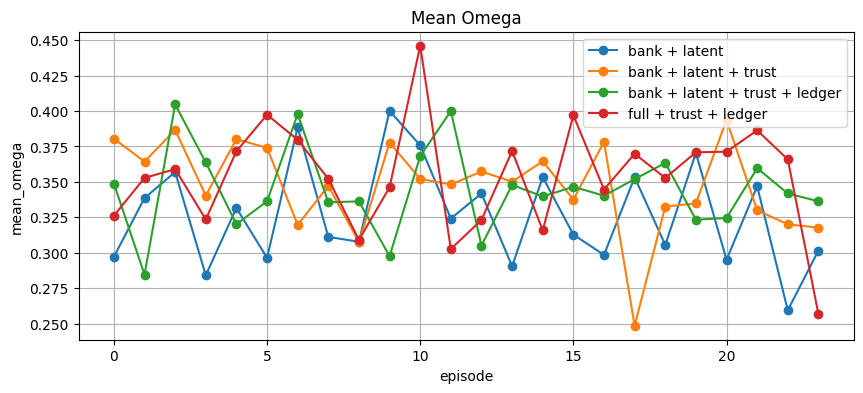

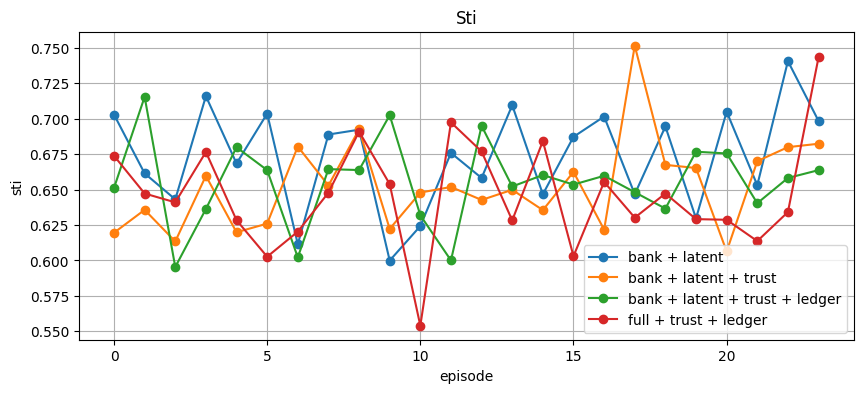

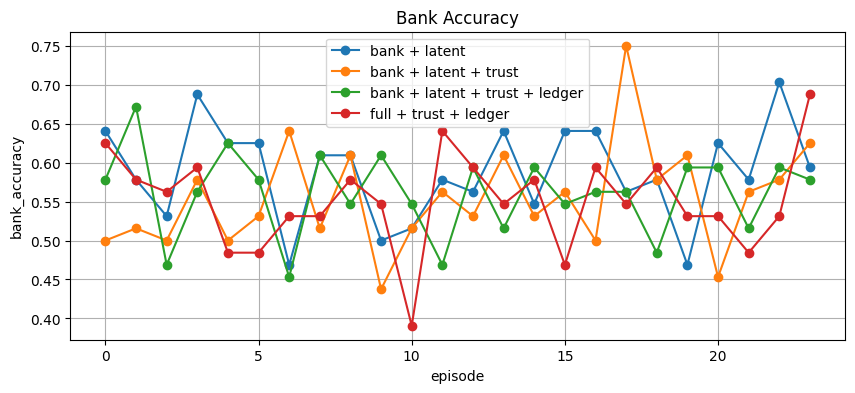

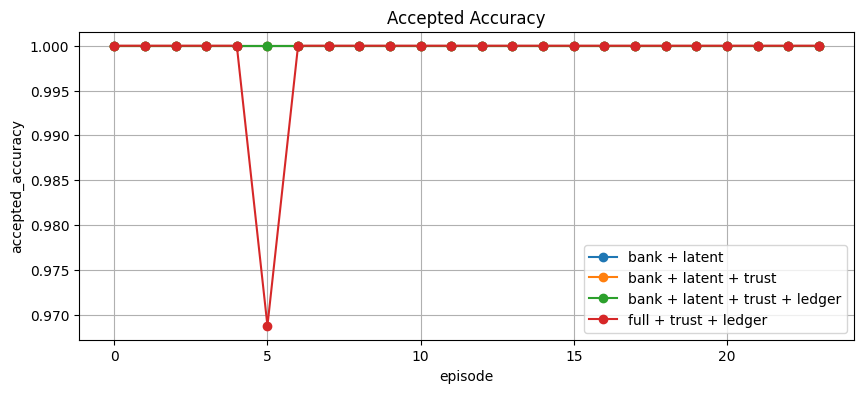

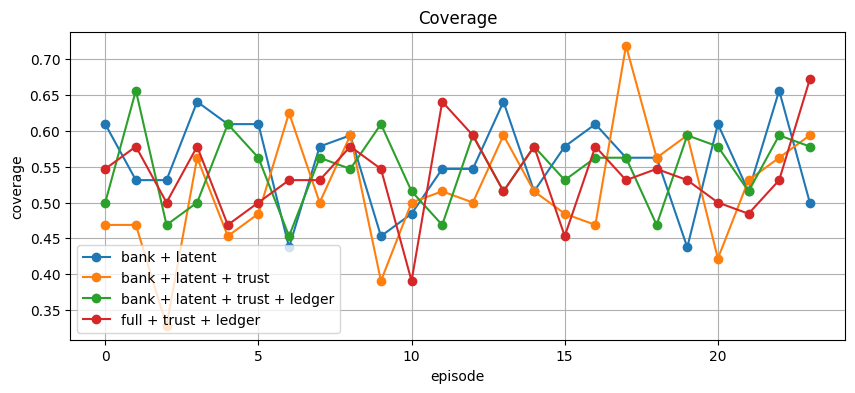

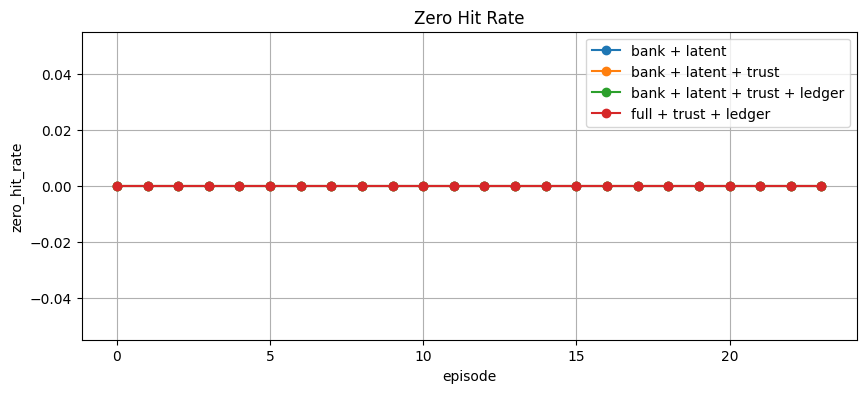

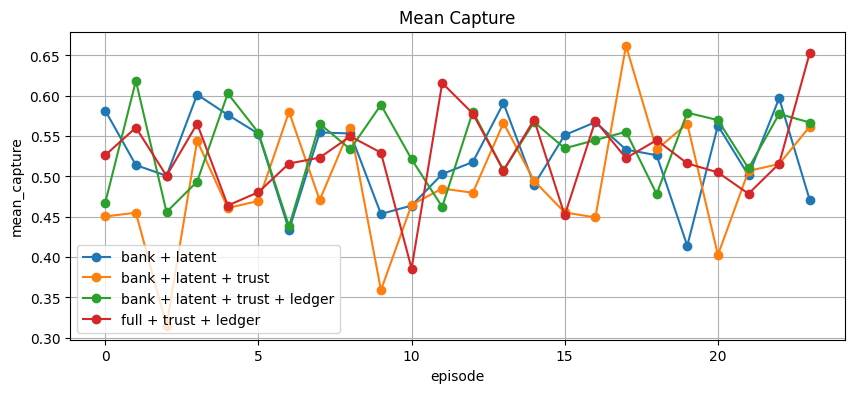

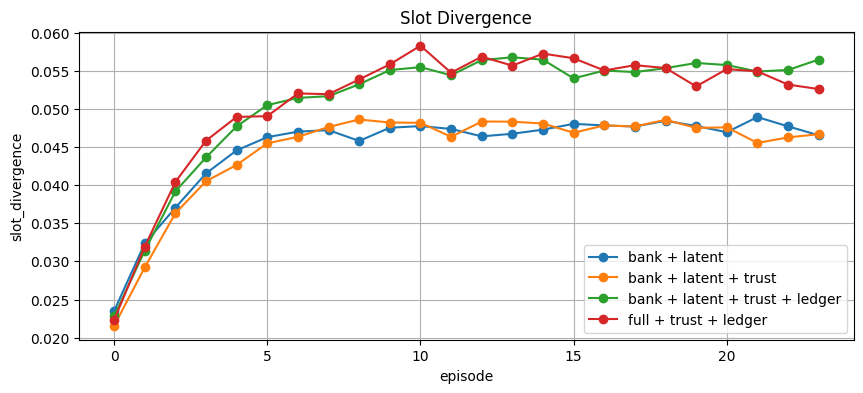

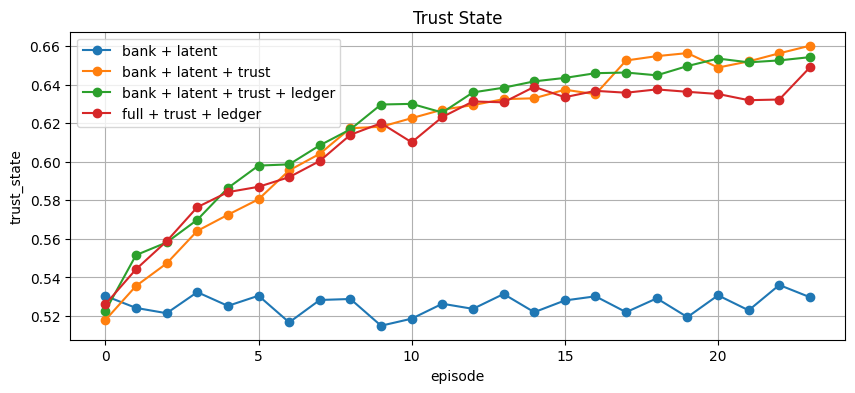

In [11]:

metrics = [
    "mean_omega",
    "sti",
    "bank_accuracy",
    "accepted_accuracy",
    "coverage",
    "zero_hit_rate",
    "mean_capture",
    "slot_divergence",
    "trust_state",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    for mode in modes:
        df = results[results["mode"] == mode]
        plt.plot(df["episode"], df[metric], marker="o", label=mode)
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("episode")
    plt.ylabel(metric)
    plt.legend(loc="best")
    plt.show()



## Zero summary

Now we compare early vs late on the actual closure metrics.


In [12]:

summary_rows = []

for mode in modes:
    df = results[results["mode"] == mode].reset_index(drop=True)
    early = df.iloc[:6]
    late = df.iloc[-6:]

    summary_rows.append({
        "mode": mode,
        "early_omega": float(early["mean_omega"].mean()),
        "late_omega": float(late["mean_omega"].mean()),
        "omega_gain_to_zero": float(early["mean_omega"].mean() - late["mean_omega"].mean()),
        "early_sti": float(early["sti"].mean()),
        "late_sti": float(late["sti"].mean()),
        "sti_gain": float(late["sti"].mean() - early["sti"].mean()),
        "early_zero_hit": float(early["zero_hit_rate"].mean()),
        "late_zero_hit": float(late["zero_hit_rate"].mean()),
        "zero_hit_gain": float(late["zero_hit_rate"].mean() - early["zero_hit_rate"].mean()),
        "early_acc": float(early["accepted_accuracy"].mean()),
        "late_acc": float(late["accepted_accuracy"].mean()),
        "accepted_gain": float(late["accepted_accuracy"].mean() - early["accepted_accuracy"].mean()),
        "mean_bank_accuracy": float(df["bank_accuracy"].mean()),
        "mean_trust_state": float(df["trust_state"].mean()),
        "mean_divergence": float(df["slot_divergence"].mean()),
    })

zero_df = pd.DataFrame(summary_rows).sort_values(
    ["omega_gain_to_zero", "sti_gain", "zero_hit_gain", "accepted_gain"],
    ascending=False
)

zero_df


,mode,early_omega,late_omega,omega_gain_to_zero,early_sti,late_sti,sti_gain,early_zero_hit,late_zero_hit,zero_hit_gain,early_acc,late_acc,accepted_gain,mean_bank_accuracy,mean_trust_state,mean_divergence
1,bank + latent + trust,0.370949,0.338090,0.032859,0.629051,0.661910,0.032859,0.0,0.0,0.0,1.000000,1.0,0.000000,0.554036,0.614589,0.044596
3,full + trust + ledger,0.355041,0.350614,0.004428,0.644959,0.649386,0.004428,0.0,0.0,0.0,0.994792,1.0,0.005208,0.551432,0.611036,0.051108
0,bank + latent,0.317408,0.313100,0.004309,0.682592,0.686900,0.004309,0.0,0.0,0.0,1.000000,1.0,0.000000,0.587891,0.525998,0.044927
2,bank + latent + trust + ledger,0.343007,0.341465,0.001542,0.656993,0.658535,0.001542,0.0,0.0,0.0,1.000000,1.0,0.000000,0.560547,0.618884,0.050983


In [13]:

def zero_qualifies(row):
    return (
        row["omega_gain_to_zero"] > 0 and
        row["sti_gain"] > 0 and
        row["zero_hit_gain"] > 0
    )

zero_df["approaches_zero"] = zero_df.apply(zero_qualifies, axis=1)
zero_df


,mode,early_omega,late_omega,omega_gain_to_zero,early_sti,late_sti,sti_gain,early_zero_hit,late_zero_hit,zero_hit_gain,early_acc,late_acc,accepted_gain,mean_bank_accuracy,mean_trust_state,mean_divergence,approaches_zero
1,bank + latent + trust,0.370949,0.338090,0.032859,0.629051,0.661910,0.032859,0.0,0.0,0.0,1.000000,1.0,0.000000,0.554036,0.614589,0.044596,False
3,full + trust + ledger,0.355041,0.350614,0.004428,0.644959,0.649386,0.004428,0.0,0.0,0.0,0.994792,1.0,0.005208,0.551432,0.611036,0.051108,False
0,bank + latent,0.317408,0.313100,0.004309,0.682592,0.686900,0.004309,0.0,0.0,0.0,1.000000,1.0,0.000000,0.587891,0.525998,0.044927,False
2,bank + latent + trust + ledger,0.343007,0.341465,0.001542,0.656993,0.658535,0.001542,0.0,0.0,0.0,1.000000,1.0,0.000000,0.560547,0.618884,0.050983,False



## Read the result

This notebook no longer asks:
- did the system merely improve?

It asks:
- did residual collapse?
- did STI rise?
- did zero-hit rate increase?

The first mode that satisfies those together is the first plausible
continuity package under a zero-seeking law.
